<a href="https://colab.research.google.com/github/micplachta/um2026/blob/main/lab07_gradient_boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework Assignment: Understanding Binary Cross-Entropy in the Forward Stagewise Procedure
-----------------------------

## The Problem

In this assignment, you will demonstrate that adding a new constant predictor in the forward stagewise procedure to an already existing predictor from a previous stage, $f_{m-1}(x_i)$ (which we will denote as $f_i$ for ease of notation), may be for certain loss functions fundamentally more challenging than building a constant predictor from scratch. You will work with the binary cross-entropy loss defined as

$$
L(y, z) = -y \log(\sigma(z)) - (1 - y) \log(1 - \sigma(z)),
$$

where

- $y_i \in \{0,1\}$ are the binary labels,
- $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the sigmoid function.

For the purposes of this assignment, assume that you are given:

- A dataset of binary labels $y_i$.
- **Two constants: $m$ (the number of ones) and $k$ (the number of zeros)** in the labels in the dataset.
- A set of predictions $f_i = f_{m-1}(x_i)$ obtained from a previous stage, where the $f_i$ values are generated randomly from a normal distribution.

### The assignment will explore two scenarios:

### Scenario A: Fitting a Constant Predictor from Scratch

In this scenario, you are building a predictor from scratch. The task is to find the optimal constant value $\lambda$ that minimizes the binary cross-entropy loss over the dataset. Formulate the optimization problem as:

$$
\lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, \lambda).
$$



### Scenario B: Fitting the m-th Predictor in the Forward Stagewise Procedure

Now assume you already have an existing predictor $f_i = f_{m-1}(x_i)$. Rather than predicting from scratch, you wish to find an optimal additive correction $\lambda$ such that the updated prediction for each data point becomes

$$
 f_i + \lambda,
$$

and the corresponding binary cross-entropy loss is given by

$$
\lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, f_i + \lambda).
$$


## Research Questions

In this assignment you will answer the following questions:

- Why is finding an optimal additive shift $\lambda$ in the forward stagewise procedure fundamentally harder than directly fitting a single-parameter predictor from scratch?
- How does the complexity of the loss landscape differ between these two scenarios? Discuss the differences in the shape and smoothness of the loss function in both cases.

## Tasks & Deliverables

1. **Derivation and Analysis**

  **Scenario A:**
  - Derive explicitly the optimal $\lambda$ for fitting from scratch, i.e., solve
    
    $$
    \lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, \lambda)
    $$
    
    and express the answer in terms of $m$ and $k$.
    *Hint:* First, write the derivative of the loss with respect to $\lambda$ and set it to zero to obtain an implicit equation.

  - **Interpretation:**
  Provide a clear interpretation of your derived optimal $\lambda$. What does this constant represent in terms of the dataset's label distribution?

  **Scenario B:**
  - Derive the implicit equation that $\lambda$ must satisfy in the additive shift scenario:
    
    $$
    \lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, f_i + \lambda).
    $$
    *Hint:* First, write the derivative of the loss with respect to $\lambda$ and set it to zero to obtain an implicit equation.

  - **Discussion:**
    Explain clearly why this implicit equation has no simple closed-form solution, unlike the previous case. What role does the non-linearity of the sigmoid function (in the binary cross-entropy loss) play in this difficulty?

2. **Loss Landscape Exploration (Python)**

  Write a Python code that:

  - Uses provided values for $n$, and for $k$ and $m$ (the number of zeros and ones in the labels, respectively), $k+m=n$.
  - Generates a set of predictions $f_i$ by sampling from a normal distribution.
  - Plots the binary cross-entropy loss as a function of $\lambda$ for:
    - Scenario A:
      $$
      \text{plot } \sum_{i=1}^{n} L(y_i, \lambda) \text{ as a function of }\lambda
      $$
    - Scenario B:
      $$
      \text{plot } \sum_{i=1}^{n} L(y_i, f_i + \lambda) \text{ as a function of }\lambda
      $$
  - **Discussion:**
  Is the loss landscape in Scenario A simpler or more complex than in Scenario B? Is it multimodal or unimodal? If so, is it thinkable the lambda minimizer in Scenario B can be found numerically? Where does the difficulty in Scenario B come from: the non-linearity of the problem or a complex loss landscape?

3. **Report**  
   - Summarize your theoretical insights and empirical findings in a **Colab notebook**.
   - Include the relevant proofs, code, discussion, and conclusions.
   - Place the notebook in your **GitHub repository** for this course, add a link to it in your README.md and add an **“Open in Colab”** badge in the notebook so it can be launched directly.



#Solution

1. To minimize the total loss we calculate the derivative. For sigmoid function we have
$$
\sigma(z)'= \frac{e^{-z}}{(1 + e^{-z})^2} = \frac{1}{1+e^{-z}} \left( 1 - \frac{1}{1+e^{-z}} \right) = \sigma(z) (1 - \sigma(z))
$$
and thus
$$
\frac{\partial L}{\partial \lambda}(y_i, \lambda) = -y_i \frac{1}{\sigma(\lambda)} \sigma(\lambda) (1 - \sigma(\lambda)) + (1 - y_i) \frac{1}{1 - \sigma(\lambda)} \sigma(\lambda) (1 - \sigma(\lambda)) = \sigma(\lambda) - y_i.
$$
The derivative is $n\sigma(\lambda) - \sum_{k=1}^n y_i$. It is equal to zero when
$$
\lambda^* = \log \left( \frac{\sum y_i}{n - \sum y_i} \right) = \log \left( \frac{m}{k} \right).
$$
This optimal $\lambda$ is the log of ratio of successes to failures so the log of the odds of a success (the log of how much a success is more probable than a failure).

2. Now we have
$$
\frac{\partial L}{\partial \lambda}(y_i, f_i + \lambda) = \sigma(f_i + \lambda) - y_i,
$$
so to minimize we set $\sum_{k=1}^n(\sigma(f_i + \lambda) - y_i) = 0$ and we obtain
$$
\sum_{k=1}^n \frac{1}{1 + e^{-f_i - \lambda}} = m.
$$
The functions $\lambda \rightarrow \sigma(f_i + \lambda)$ are nonlinear. We can't algebraically isolate the $\lambda$ and solve the equation.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit as sigmoid

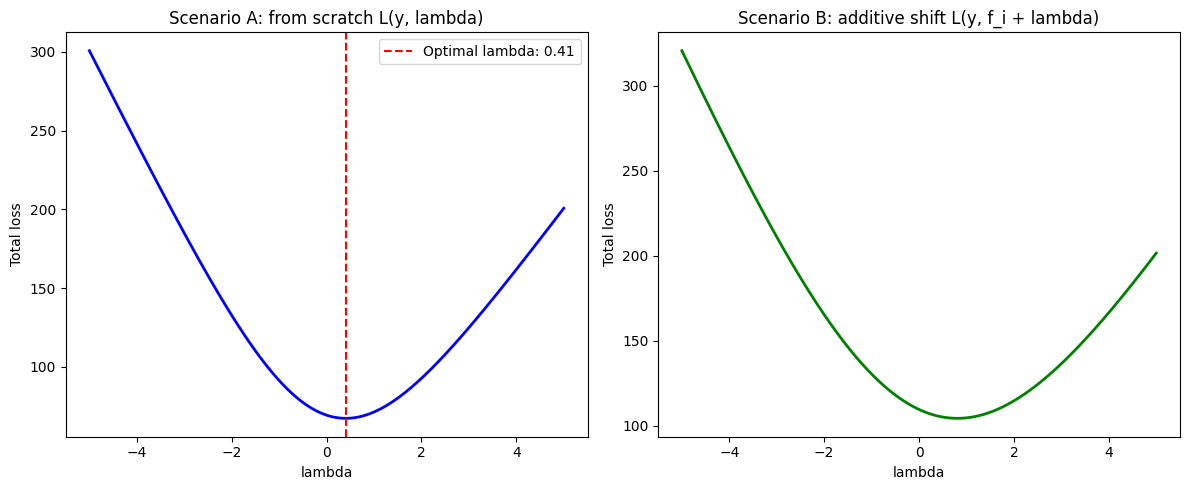

In [12]:
np.random.seed(42)
m, k = 60, 40
n = m + k
y = np.array([1]*m + [0]*k)
f_i = np.random.normal(0, 2, n)

def bce_loss(y_true, z):
    return -y_true * np.log(sigmoid(z)) - (1 - y_true) * np.log(1 - sigmoid(z))

lambdas = np.linspace(-5, 5, 500)
loss_a = [np.sum(bce_loss(y, l)) for l in lambdas]
loss_b = [np.sum(bce_loss(y, f_i + l)) for l in lambdas]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lambdas, loss_a, color='blue', lw=2)
plt.axvline(np.log(m/k), color='red', linestyle='--', label=f'Optimal lambda: {np.log(m/k):.2f}')
plt.title("Scenario A: from scratch L(y, lambda)")
plt.xlabel("lambda")
plt.ylabel("Total loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(lambdas, loss_b, color='green', lw=2)
plt.title("Scenario B: additive shift L(y, f_i + lambda)")
plt.xlabel("lambda")
plt.ylabel("Total loss")

plt.tight_layout()
plt.show()

Both landscapes are unimodal and are also convex! That means that finding a numerical solution to the minimization problem in the scenario B is very easy.The difficulty in scenario B comes not from the complex loss landscape but the inability to solve it analytically.